# Exploración de delitos desde PostGIS (prototipo)
**Objetivo:** explorar la distribución de los delitos por AGEB, categoría y hora, y calcular un primer Moran global, **leyendo directo del warehouse** (esquema `staging`).

> Es un prototipo: los KPIs finales deben salir de las vistas de `sql/03_views.sql`. Aquí se usan **conteos** porque la población del Censo todavía no está cargada; la tasa de delitos por 1,000 habitantes se calculará cuando exista.

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from sqlalchemy import text
from libpysal.weights import Queen
from esda.moran import Moran
from src.db import get_engine
from src.config import ROOT

engine = get_engine()
with engine.connect() as conn:
    print(conn.execute(text("SELECT PostGIS_Version()")).scalar())

3.4 USE_GEOS=1 USE_PROJ=1 USE_STATS=1


## 1. Estado de la carga

In [2]:
estatus = pd.read_sql(
    "SELECT estatus_asignacion, COUNT(*) AS n FROM staging.stg_delitos GROUP BY 1 ORDER BY 2 DESC", engine)
estatus["%"] = (estatus["n"] / estatus["n"].sum() * 100).round(2)
estatus

,estatus_asignacion,n,%
0,asignado,227837,94.00
1,sin_coordenadas_validas,14147,5.84
2,dentro_cdmx_sin_ageb,357,0.15
3,fuera_cdmx,51,0.02


## 2. Delitos por AGEB
Solo se cuentan los delitos con estatus `asignado`. Las AGEB sin ningún delito se rellenan con 0.

In [3]:
agebs = gpd.read_postgis(
    "SELECT cvegeo, nomgeo, area_km2, geometry FROM staging.stg_agebs ORDER BY cvegeo",
    engine, geom_col="geometry")

conteo = pd.read_sql(
    "SELECT cvegeo, COUNT(*) AS n_delitos FROM staging.stg_delitos "
    "WHERE estatus_asignacion = 'asignado' GROUP BY 1", engine)

agebs = agebs.merge(conteo, on="cvegeo", how="left")
agebs["n_delitos"] = agebs["n_delitos"].fillna(0).astype(int)
agebs["delitos_km2"] = agebs["n_delitos"] / agebs["area_km2"]

print("AGEB:", len(agebs), "| con al menos 1 delito:", (agebs["n_delitos"] > 0).sum())
agebs["n_delitos"].describe()

AGEB: 2431 | con al menos 1 delito: 2420


count    2431.000000
mean       93.721514
std        91.345445
min         0.000000
25%        41.000000
50%        72.000000
75%       118.000000
max      1480.000000
Name: n_delitos, dtype: float64

In [4]:
agebs.sort_values("n_delitos", ascending=False)[["cvegeo", "nomgeo", "n_delitos", "area_km2"]].head(10)

,cvegeo,nomgeo,n_delitos,area_km2
2148,0901500011534,Cuauhtémoc,1480,0.282040
2070,0901500010748,Cuauhtémoc,1320,0.314311
2045,090150001049A,Cuauhtémoc,1007,0.617860
2098,0901500011036,Cuauhtémoc,830,0.361654
879,0900700012475,Iztapalapa,798,2.264929
449,0900500011805,Gustavo A. Madero,654,0.718816
282,0900400010369,Cuajimalpa de Morelos,638,3.168901
2091,090150001095A,Cuauhtémoc,622,0.237098
2083,0901500010875,Cuauhtémoc,599,0.416955
1896,0901400010026,Benito Juárez,563,0.246747


In [5]:
por_alcaldia = (agebs.groupby("nomgeo")
                .agg(agebs=("cvegeo", "count"), delitos=("n_delitos", "sum"))
                .sort_values("delitos", ascending=False))
por_alcaldia

,agebs,delitos
nomgeo,,
Cuauhtémoc,153,32875
Iztapalapa,458,32627
Gustavo A. Madero,305,23204
Benito Juárez,102,17268
Coyoacán,156,16519
Álvaro Obregón,199,15523
Tlalpan,207,14487
Miguel Hidalgo,130,13977
Venustiano Carranza,151,13315


## 3. Delitos por categoría y por hora

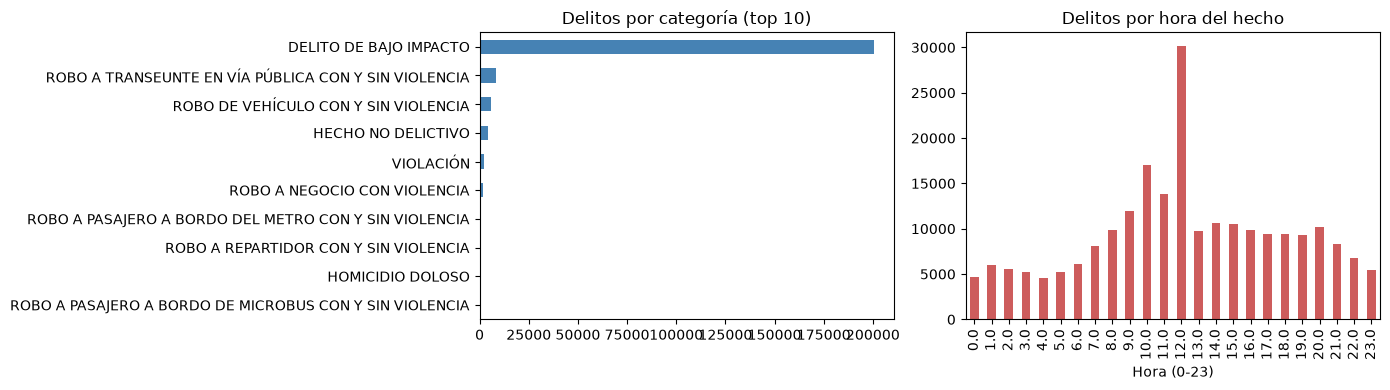

In [6]:
cat = pd.read_sql(
    "SELECT categoria_delito, COUNT(*) AS n FROM staging.stg_delitos "
    "WHERE estatus_asignacion = 'asignado' GROUP BY 1 ORDER BY 2 DESC", engine)
hora = pd.read_sql(
    "SELECT hora, COUNT(*) AS n FROM staging.stg_delitos "
    "WHERE estatus_asignacion = 'asignado' AND hora IS NOT NULL GROUP BY 1 ORDER BY 1", engine)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
cat.head(10).plot(kind="barh", x="categoria_delito", y="n", ax=axes[0], legend=False, color="steelblue")
axes[0].invert_yaxis(); axes[0].set_title("Delitos por categoría (top 10)"); axes[0].set_ylabel("")
hora.plot(kind="bar", x="hora", y="n", ax=axes[1], legend=False, color="indianred")
axes[1].set_title("Delitos por hora del hecho"); axes[1].set_xlabel("Hora (0-23)")
plt.tight_layout()
plt.show()

## 4. Mapa de delitos por AGEB
Se usa la escala logarítmica (`log1p`) porque la distribución está muy sesgada.

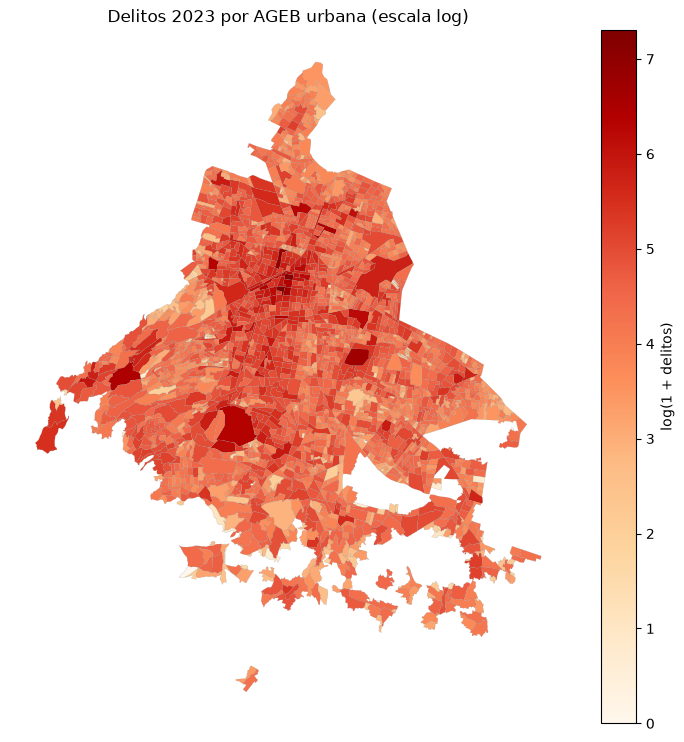

In [7]:
fig, ax = plt.subplots(figsize=(9, 9))
agebs.assign(log_delitos=np.log1p(agebs["n_delitos"])).plot(
    column="log_delitos", cmap="OrRd", legend=True, linewidth=0.1, edgecolor="grey", ax=ax,
    legend_kwds={"label": "log(1 + delitos)"})
ax.set_title("Delitos 2023 por AGEB urbana (escala log)")
ax.set_axis_off()

out = ROOT / "outputs" / "maps"
out.mkdir(parents=True, exist_ok=True)
fig.savefig(out / "delitos_por_ageb_postgis.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Moran global (prototipo)
Regla de vecindad: contigüidad Queen de primer orden, con pesos estandarizados por fila. Las **islas** (AGEB sin vecinos) se excluyen, porque su rezago espacial no está definido.

In [8]:
agebs = agebs.reset_index(drop=True)
w0 = Queen.from_dataframe(agebs, use_index=False, silence_warnings=True)
print("Islas excluidas:", len(w0.islands))

conectadas = agebs.drop(index=w0.islands).reset_index(drop=True)
w = Queen.from_dataframe(conectadas, use_index=False, silence_warnings=True)
w.transform = "R"
print("AGEB analizadas:", w.n, "| vecinos promedio:", round(w.mean_neighbors, 2))

Islas excluidas: 1
AGEB analizadas: 2430 | vecinos promedio: 5.94


In [9]:
np.random.seed(42)
resultados = {}
for var in ["n_delitos", "delitos_km2"]:
    m = Moran(conectadas[var].values, w, permutations=999)
    resultados[var] = {"I de Moran": round(m.I, 4), "E[I]": round(m.EI, 4),
                       "z (sim)": round(m.z_sim, 2), "p (sim)": m.p_sim}
pd.DataFrame(resultados).T

,I de Moran,E[I],z (sim),p (sim)
n_delitos,0.4228,-0.0004,34.56,0.001
delitos_km2,0.5563,-0.0004,46.22,0.001


## 6. Interpretación

- **I de Moran:** El índice de Moran permite identificar si existe un patrón espacial en los delitos entre las AGEB. Un valor cercano a 0 indica ausencia de un patrón espacial claro; un valor positivo indica que AGEB con valores similares tienden a estar juntas, formando clusters, mientras que un valor negativo indica una distribución más alternada. Se compararon los resultados para `n_delitos` y `delitos_km2`.

- **Significancia:** La significancia se evaluó mediante **999 permutaciones**. Un valor de **p (sim) < 0.05** indica que el patrón espacial observado es estadísticamente significativo. Con 999 permutaciones, el menor valor posible de p es 0.001.

- **Conteo vs densidad:** Se comparó el I de Moran calculado con el **conteo de delitos (`n_delitos`)** y con la **densidad de delitos por km² (`delitos_km2`)**. Si los valores de Moran cambian considerablemente entre ambas medidas, esto indica que el tamaño de las AGEB influye en el patrón observado. La comparación permite determinar si el patrón espacial se mantiene al normalizar los delitos por área.

- **Limitaciones:**
  - Los conteos de delitos dependen del tamaño de la AGEB y de su población. Por ello, la versión final del análisis deberá utilizar la **tasa de delitos por cada 1,000 habitantes**, utilizando los datos del Censo.
  - La regla de vecindad utilizada condiciona los resultados del análisis espacial, por lo que debe considerarse la comparación con otras reglas de vecindad realizada en `02_vecindad_espacial.ipynb`.
  - Existe un desfase temporal entre las fuentes utilizadas: **Censo 2020, delitos de 2023 y DENUE de 05/2026**.
  - Una asociación espacial no implica causalidad. El análisis permite identificar patrones espaciales, pero no demuestra relaciones causales entre las variables.
  - 